# Field Evaluations in Chain

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import treams

In [3]:
k0 = 2 * np.pi / 700
materials = [treams.Material(-16.5 + 1j), treams.Material()]
lmax = 3
radii = [75, 75]
positions = [[-30, 0, -75], [30, 0, 75]]
lattice = 300
kz = 0

In [4]:
spheres = [treams.TMatrix.sphere(lmax, k0, r, materials) for r in radii]
chain = treams.TMatrix.cluster(spheres, positions).latticeinteraction.solve(lattice, kz)

In [5]:
inc = treams.plane_wave([k0, 0, 0], [0, 0, 1], k0=chain.k0, material=chain.material)
sca = chain @ inc.expand(chain.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:625: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_sw(


In [6]:
x = np.linspace(-150, 150, 31)
y = 0
z = np.linspace(-150, 150, 31)
xx, zz = np.meshgrid(x, z, indexing="ij")
yy = np.full_like(xx, y)
grid = np.stack((xx, yy, zz), axis=-1)

In [7]:
ez = np.zeros_like(xx)
valid = chain.valid_points(grid, radii)
vals = []
for i, r in enumerate(grid[valid]):
    swb = treams.SphericalWaveBasis.default(1, positions=[r])
    field = sca.expandlattice(basis=swb).efield(r)
    vals.append(np.real(inc.efield(r)[2] + field[2]))
ez[valid] = vals
ez[~valid] = np.nan

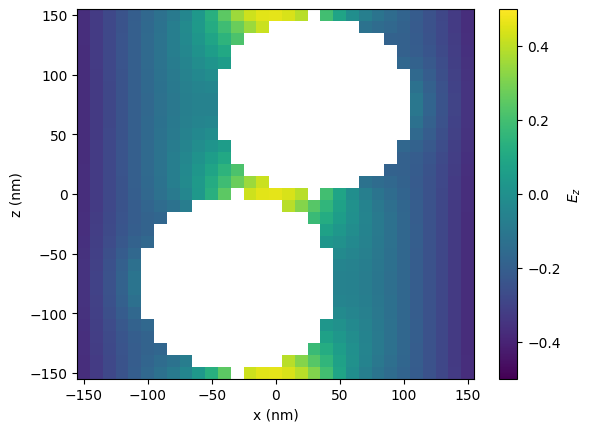

In [8]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    xx, zz, ez, shading="nearest", vmin=-0.5, vmax=0.5,
)
cb = plt.colorbar(pcm)
cb.set_label("$E_z$")
ax.set_xlabel("x (nm)")
ax.set_ylabel("z (nm)")
fig.show()